1.LOAD DATASET

In [1]:
import pandas as pd

PLATFORM = "Twitter"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/twitter_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/twitter_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(35740, 56)
(8936, 56)


In [2]:
X_train = train_df.drop(columns=["popularity"])
y_train = train_df["popularity"]

X_test = test_df.drop(columns=["popularity"])
y_test = test_df["popularity"]

In [3]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

model = XGBClassifier(

    # objective
    objective="binary:logistic",

    # evaluation metric
    eval_metric="logloss",

    # tree settings
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,

    # randomness
    random_state=42,

    # parallel processing
    n_jobs=-1
)

In [4]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [6]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [7]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      7138
           1       0.72      0.50      0.59      1798

    accuracy                           0.86      8936
   macro avg       0.80      0.73      0.75      8936
weighted avg       0.85      0.86      0.85      8936



In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[6781  357]
 [ 891  907]]


In [9]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
               feature  importance
3            followers    0.354819
21       large_account    0.058787
46     media_type_Poll    0.017854
42     language_Korean    0.017159
35        topic_Travel    0.015573
38     language_French    0.015263
26       topic_Fashion    0.015159
23       topic_Climate    0.014880
28          topic_Food    0.014860
27       topic_Finance    0.014650
33        topic_Sports    0.014634
11            hour_sin    0.013998
50     location_Europe    0.013933
9   sentiment_negative    0.013569
29        topic_Gaming    0.013323


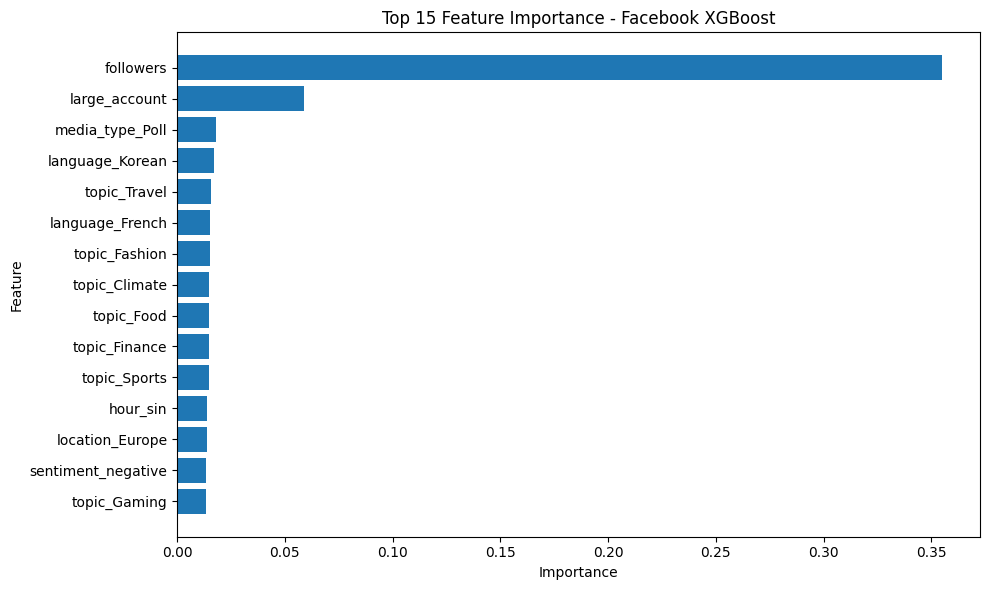

In [10]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Facebook XGBoost"
)

plt.tight_layout()

plt.show()